# Model Card Generator Demo - Lesson 5: AI Model Governance

**Scenario**: TechVault Solutions — B2B SaaS company providing cloud-based data management

This demo shows how to generate a Model Card and track model lifecycle for a single AI model.

---

### Quick Reference: Key Concepts

**Model Card Sections (Google Standard)**:
1. Model Details — ID, name, version, type, framework, developers, dates
2. Intended Use — Primary use cases, users, out-of-scope uses
3. Training Data — Sources, size, preprocessing, quality issues
4. Performance Metrics — Task-specific metrics, latency, business impact
5. Ethical Considerations — Bias testing, known issues, fairness metrics, mitigation
6. Limitations — Known limitations, failure modes, edge cases
7. Recommendations & Monitoring — Monitoring plan, update schedule, governance

**Model Lifecycle Stages**: Development → Staging → Production → Retired

**Risk Tiers**: Critical (life-safety/financial), High (significant business impact), Medium (moderate impact), Minimal (low risk)

In [1]:
import pandas as pd
from datetime import datetime

print(f"pandas version: {pd.__version__}")
print(f"Current date: {datetime.now().strftime('%Y-%m-%d')}")

pandas version: 2.3.3
Current date: 2026-03-23


## Step 1: Define Model Metadata

In [2]:
# DocuMind AI - TechVault's Document Summarization Model
model_metadata = {
    "model_id": "M001",
    "model_name": "DocuMind AI",
    "version": "3.2.0",
    "model_type": "Generative AI (Large Language Model)",
    "framework": "Fine-tuned LLM with RAG pipeline",
    "developers": ["Dr. Anika Mehta", "AI Products Team"],
    "department": "AI Products",
    "date_created": "2023-09-01",
    "last_updated": "2025-01-15",
    "intended_use": "Automated summarization of enterprise documents (contracts, reports, whitepapers) with key insight extraction",
    "primary_users": "Enterprise client employees (legal, operations, management)",
    "out_of_scope_uses": [
        "Legal advice generation",
        "Document editing/modification",
        "Translation",
        "Personal document processing"
    ],
    "training_data_sources": [
        "Licensed enterprise document corpus (500K docs)",
        "Anonymized client samples",
        "Public SEC filings",
        "Academic papers"
    ],
    "training_data_size": "~500K documents, 2.1B tokens",
    "preprocessing": [
        "Document parsing",
        "Text extraction",
        "PII redaction",
        "Deduplication",
        "Quality filtering"
    ],
    "data_quality_issues": "OCR artifacts in ~8% of corpus; industry jargon underrepresented; temporal bias toward recent documents",
    "performance_metrics": {
        "rouge_l": "0.68",
        "key_insight_precision": "87%",
        "key_insight_recall": "82%",
        "latency_per_page": "1.2s",
        "latency_p95": "2.8s",
        "time_to_insight_improvement": "-65%",
        "user_satisfaction": "4.2/5.0"
    },
    "bias_testing": {
        "tests_conducted": [
            "Language bias",
            "Industry sector bias",
            "Document length bias",
            "Terminology inclusivity"
        ],
        "known_issues": [
            "Higher quality for legal vs technical docs (ROUGE-L 0.72 vs 0.63)",
            "Underperforms on docs <2 pages"
        ],
        "demographic_variation": {
            "language": "Within 5% across EN/ES/FR, German 8% lower"
        },
        "fairness_metrics": {
            "information_extraction_parity": "0.91 across industries",
            "key_insight_recall_parity": "Within 4% across doc types"
        }
    },
    "mitigation_strategies": [
        "Supplemental German training data",
        "Domain-specific fine-tuning",
        "Quarterly bias audits"
    ],
    "limitations": [
        "Cannot process images/charts",
        "Max 100 pages",
        "Struggles with math notation",
        "No real-time learning"
    ],
    "failure_modes": [
        "Hallucinated details for ambiguous content",
        "May miss critical clauses in nested legal language",
        "Latency spikes >50 pages"
    ],
    "edge_cases": [
        "Scanned docs with poor OCR",
        "Multi-language docs",
        "Heavily formatted docs"
    ],
    "monitoring_plan": "Daily latency/error tracking; Weekly ROUGE-L sampling; Monthly bias review; Quarterly comprehensive review",
    "update_schedule": "Quarterly retraining; Monthly RAG updates; Emergency patches for >10% performance drops",
    "owner": "Dr. Anika Mehta",
    "next_review_date": "2025-04-15"
}

print("✓ Model metadata defined")
print(f"  Model: {model_metadata['model_name']} (v{model_metadata['version']})")
print(f"  Owner: {model_metadata['owner']}")
print(f"  Department: {model_metadata['department']}")

✓ Model metadata defined
  Model: DocuMind AI (v3.2.0)
  Owner: Dr. Anika Mehta
  Department: AI Products


## Step 2: Create Model Card Generator Function

In [3]:
def generate_model_card_markdown(metadata):
    """
    Generate a Model Card in Markdown format from metadata dictionary.
    Simplified version for demo purposes.
    """
    lines = []
    
    # Title
    lines.append(f"# Model Card: {metadata['model_name']}\n")
    lines.append(f"**Model ID**: {metadata['model_id']} | **Version**: {metadata['version']}\n")
    
    # Model Details
    lines.append("## Model Details\n")
    lines.append(f"- **Model Type**: {metadata['model_type']}")
    lines.append(f"- **Framework**: {metadata['framework']}")
    lines.append(f"- **Developers**: {', '.join(metadata['developers'])}")
    lines.append(f"- **Owner**: {metadata['owner']}")
    lines.append(f"- **Department**: {metadata['department']}")
    lines.append(f"- **Created**: {metadata['date_created']} | **Last Updated**: {metadata['last_updated']}\n")
    
    # Intended Use
    lines.append("## Intended Use\n")
    lines.append(f"**Primary Purpose**: {metadata['intended_use']}\n")
    lines.append(f"**Primary Users**: {metadata['primary_users']}\n")
    lines.append("**Out-of-Scope Uses**:")
    for use in metadata['out_of_scope_uses']:
        lines.append(f"- {use}")
    lines.append("")
    
    # Training Data
    lines.append("## Training Data\n")
    lines.append("**Data Sources**:")
    for source in metadata['training_data_sources']:
        lines.append(f"- {source}")
    lines.append(f"\n**Data Size**: {metadata['training_data_size']}\n")
    lines.append("**Preprocessing**:")
    for step in metadata['preprocessing']:
        lines.append(f"- {step}")
    lines.append(f"\n**Quality Issues**: {metadata['data_quality_issues']}\n")
    
    # Performance Metrics
    lines.append("## Performance Metrics\n")
    for metric, value in metadata['performance_metrics'].items():
        metric_name = metric.replace('_', ' ').title()
        lines.append(f"- **{metric_name}**: {value}")
    lines.append("")
    
    # Ethical Considerations
    lines.append("## Ethical Considerations & Bias Testing\n")
    lines.append("**Tests Conducted**:")
    for test in metadata['bias_testing']['tests_conducted']:
        lines.append(f"- {test}")
    
    lines.append("\n**Known Bias Issues**:")
    for issue in metadata['bias_testing']['known_issues']:
        lines.append(f"- {issue}")
    
    lines.append("\n**Demographic Variation**:")
    for key, value in metadata['bias_testing']['demographic_variation'].items():
        lines.append(f"- {key.title()}: {value}")
    
    lines.append("\n**Fairness Metrics**:")
    for metric, value in metadata['bias_testing']['fairness_metrics'].items():
        metric_name = metric.replace('_', ' ').title()
        lines.append(f"- **{metric_name}**: {value}")
    
    lines.append("\n**Mitigation Strategies**:")
    for strategy in metadata['mitigation_strategies']:
        lines.append(f"- {strategy}")
    lines.append("")
    
    # Limitations & Failure Modes
    lines.append("## Limitations & Failure Modes\n")
    lines.append("**Known Limitations**:")
    for limitation in metadata['limitations']:
        lines.append(f"- {limitation}")
    
    lines.append("\n**Failure Modes**:")
    for failure in metadata['failure_modes']:
        lines.append(f"- {failure}")
    lines.append("")
    
    # Monitoring & Recommendations
    lines.append("## Monitoring & Recommendations\n")
    lines.append(f"**Monitoring Plan**: {metadata['monitoring_plan']}\n")
    lines.append(f"**Update Schedule**: {metadata['update_schedule']}\n")
    lines.append(f"**Next Review Date**: {metadata['next_review_date']}\n")
    
    return "\n".join(lines)

print("✓ Model Card generator function created")

✓ Model Card generator function created


## Step 3: Generate and Display Model Card

In [4]:
# Generate the Model Card
model_card = generate_model_card_markdown(model_metadata)

print("✓ Model Card generated\n")
print("="*80)
print(model_card)
print("="*80)

✓ Model Card generated

# Model Card: DocuMind AI

**Model ID**: M001 | **Version**: 3.2.0

## Model Details

- **Model Type**: Generative AI (Large Language Model)
- **Framework**: Fine-tuned LLM with RAG pipeline
- **Developers**: Dr. Anika Mehta, AI Products Team
- **Owner**: Dr. Anika Mehta
- **Department**: AI Products
- **Created**: 2023-09-01 | **Last Updated**: 2025-01-15

## Intended Use

**Primary Purpose**: Automated summarization of enterprise documents (contracts, reports, whitepapers) with key insight extraction

**Primary Users**: Enterprise client employees (legal, operations, management)

**Out-of-Scope Uses**:
- Legal advice generation
- Document editing/modification
- Translation
- Personal document processing

## Training Data

**Data Sources**:
- Licensed enterprise document corpus (500K docs)
- Anonymized client samples
- Public SEC filings
- Academic papers

**Data Size**: ~500K documents, 2.1B tokens

**Preprocessing**:
- Document parsing
- Text extraction
- PII

## Step 4A: Approval Gates Check Function

In [5]:
# Create a model inventory with lifecycle data
inventory = pd.DataFrame([
    {
        "Model ID": "M001",
        "Model Name": "DocuMind AI",
        "Lifecycle Stage": "Production",
        "Approval Status": "Approved",
        "Risk Tier": "High",
        "Owner": "Dr. Anika Mehta",
        "Last Review Date": "2025-01-15",
        "Next Review Date": "2025-04-15"
    }
])

# Convert dates
inventory['Last Review Date'] = pd.to_datetime(inventory['Last Review Date'])
inventory['Next Review Date'] = pd.to_datetime(inventory['Next Review Date'])

print("Model Inventory:")
print(inventory[['Model ID', 'Model Name', 'Lifecycle Stage', 'Approval Status', 'Risk Tier']])
print("")
print(inventory[['Model ID', 'Owner', 'Last Review Date', 'Next Review Date']])

Model Inventory:
  Model ID   Model Name Lifecycle Stage Approval Status Risk Tier
0     M001  DocuMind AI      Production        Approved      High

  Model ID            Owner Last Review Date Next Review Date
0     M001  Dr. Anika Mehta       2025-01-15       2025-04-15


In [6]:
def check_approval_gates(model_id: str, inventory_df) -> str:
    """
    Check which approval gates a model has passed.
    
    Expected workflow stages:
    1. Registration
    2. Technical Review
    3. Ethics & Bias Review
    4. Security Review
    5. Business Approval
    6. Production Deployment
    """
    model_row = inventory_df[inventory_df['Model ID'] == model_id]
    if model_row.empty:
        return f"ERROR: {model_id} not found"
    
    approval_status = model_row['Approval Status'].values[0]
    lifecycle_stage = model_row['Lifecycle Stage'].values[0]
    
    # Map approval status to report
    status_to_report = {
        "Approved": f"{model_id}: Approved — all gates passed",
        "In Review": f"{model_id}: In Review — awaiting Business Approval",
        "Pending": f"{model_id}: Pending — awaiting Ethics & Bias Review",
        "Archived": f"{model_id}: Archived — governance complete (Retired model)"
    }
    
    report = status_to_report.get(approval_status, f"{model_id}: {approval_status}")
    
    # Flag violations
    if lifecycle_stage == "Production" and approval_status not in ["Approved", "Archived"]:
        report += " [VIOLATION]"
    
    return report

# Test with the DocuMind model
print("Approval Gates Status:")
print(check_approval_gates("M001", inventory))

Approval Gates Status:
M001: Approved — all gates passed


## Step 4B: Governance Dashboard Visualization

## Step 5: Review Status Analysis

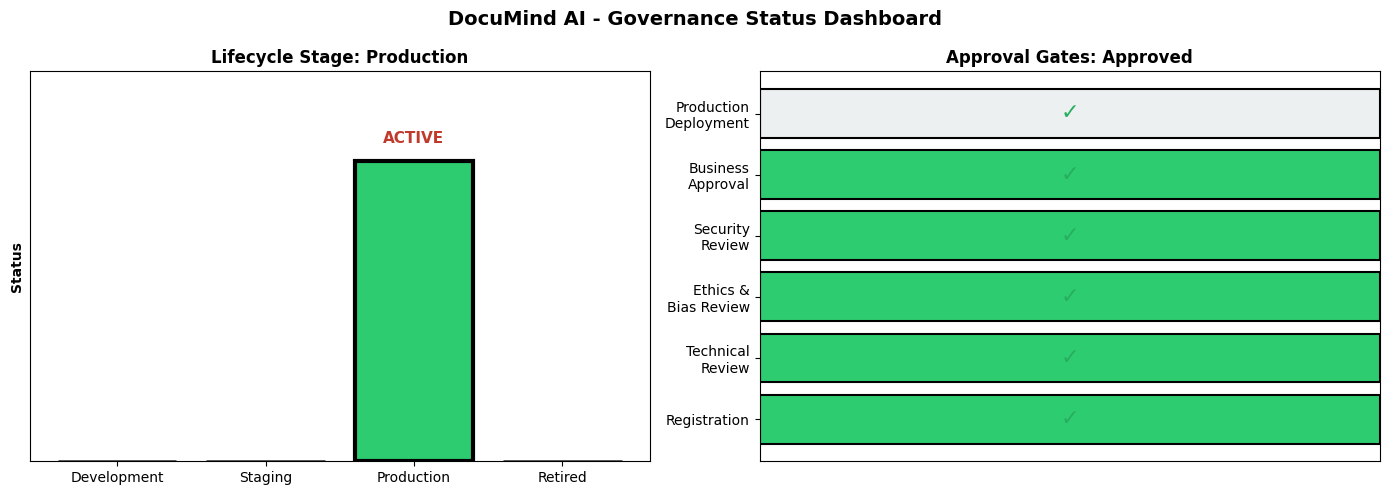


Governance Summary for Production Model:
  Approval Status: Approved
  Risk Tier: High
  Days Until Review: -342
  Owner: Dr. Anika Mehta
  Last Review: 2025-01-15
  Next Review: 2025-04-15


In [7]:
# Create a governance visualization for the single model
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DocuMind AI - Governance Status Dashboard', fontsize=14, fontweight='bold')

# Chart 1: Lifecycle Stage (single model)
ax1 = axes[0]
stages = ['Development', 'Staging', 'Production', 'Retired']
stage_colors = {'Development': '#3498db', 'Staging': '#f39c12', 'Production': '#2ecc71', 'Retired': '#95a5a6'}
model_stage = inventory['Lifecycle Stage'].values[0]
stage_counts = [1 if s == model_stage else 0 for s in stages]

colors = [stage_colors[s] for s in stages]
bars = ax1.bar(stages, stage_counts, color=colors, edgecolor='black', linewidth=2, alpha=0.7)

# Highlight the active stage
for i, (bar, stage) in enumerate(zip(bars, stages)):
    if stage == model_stage:
        bar.set_alpha(1.0)
        bar.set_linewidth(3)
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'ACTIVE', ha='center', va='bottom', fontweight='bold', fontsize=11, color='#c0392b')

ax1.set_ylabel('Status', fontweight='bold')
ax1.set_title(f'Lifecycle Stage: {model_stage}', fontweight='bold')
ax1.set_ylim(0, 1.3)
ax1.set_yticks([])
ax1.grid(axis='y', alpha=0.3)

# Chart 2: Approval Status with gates
ax2 = axes[1]
approval_status = inventory['Approval Status'].values[0]

gates = ["Registration", "Technical\nReview", "Ethics &\nBias Review", "Security\nReview", "Business\nApproval", "Production\nDeployment"]
approval_level = {"Approved": 6, "In Review": 4, "Pending": 2, "Archived": 6}.get(approval_status, 0)
gate_colors = ['#2ecc71' if i < approval_level else '#ecf0f1' for i in range(1, 7)]

bars = ax2.barh(gates, [1]*6, color=gate_colors, edgecolor='black', linewidth=1.5)

# Add checkmarks or X marks
for i, bar in enumerate(bars):
    if i < approval_level:
        ax2.text(0.5, bar.get_y() + bar.get_height()/2, '✓', 
                ha='center', va='center', fontsize=16, fontweight='bold', color='#27ae60')
    else:
        ax2.text(0.5, bar.get_y() + bar.get_height()/2, '○', 
                ha='center', va='center', fontsize=14, fontweight='bold', color='#95a5a6')

ax2.set_xlim(0, 1)
ax2.set_xticks([])
ax2.set_title(f'Approval Gates: {approval_status}', fontweight='bold')

plt.tight_layout()
plt.show()

# Print governance summary
today = pd.Timestamp(datetime.now().date())
days_until_review = (inventory['Next Review Date'].values[0] - today).days

print(f"\nGovernance Summary for {model_stage} Model:")
print(f"  Approval Status: {approval_status}")
print(f"  Risk Tier: {inventory['Risk Tier'].values[0]}")
print(f"  Days Until Review: {days_until_review}")
print(f"  Owner: {inventory['Owner'].values[0]}")
last_review = pd.Timestamp(inventory['Last Review Date'].values[0]).strftime('%Y-%m-%d')
next_review = pd.Timestamp(inventory['Next Review Date'].values[0]).strftime('%Y-%m-%d')
print(f"  Last Review: {last_review}")
print(f"  Next Review: {next_review}")

In [8]:
# Calculate review metrics
today = pd.Timestamp(datetime.now().date())
inventory['Days Until Review'] = (inventory['Next Review Date'] - today).dt.days

print(f"Current Date: {today.strftime('%Y-%m-%d')}\n")

for _, row in inventory.iterrows():
    model_id = row['Model ID']
    days_until = row['Days Until Review']
    
    if days_until < 0:
        status = f"[OVERDUE] by {abs(days_until)} days"
    elif days_until <= 30:
        status = f"[UPCOMING] Due in {days_until} days"
    else:
        status = f"[OK] Due in {days_until} days"
    
    print(f"{model_id}: {row['Model Name']}")
    print(f"  Status: {status}")
    print(f"  Owner: {row['Owner']} | Risk: {row['Risk Tier']} | Stage: {row['Lifecycle Stage']}")
    print(f"  Next Review: {row['Next Review Date'].strftime('%Y-%m-%d')}\n")

Current Date: 2026-03-23

M001: DocuMind AI
  Status: [OVERDUE] by 342 days
  Owner: Dr. Anika Mehta | Risk: High | Stage: Production
  Next Review: 2025-04-15



## Summary

This demo demonstrated the key components of AI model governance for TechVault Solutions:

1. **Model Metadata**: Structured information about DocuMind AI, including version, developers, and department
2. **Model Card Generation**: Automated creation of comprehensive governance documentation using Markdown
3. **Lifecycle Tracking**: Pandas-based inventory to manage model stages, approval status, and risk assessment
4. **Review Scheduling**: Monitoring of review dates to ensure timely governance audits

The Model Card serves as the primary governance artifact, documenting the model's capabilities, limitations, bias testing results, and recommendations for responsible deployment and monitoring in production.